<a href="https://colab.research.google.com/github/sahibbedi/cftc-cot-tracker/blob/main/WeeklyCFTCChartUpdate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance -q

Fetching 3-year CFTC CoT Data...
Fetching pricing data for basis overlay...
Generating chart...


/tmp/ipykernel_19348/3439995174.py:39: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(["BTC-USD", "BTC=F"], start=start_date, progress=False)


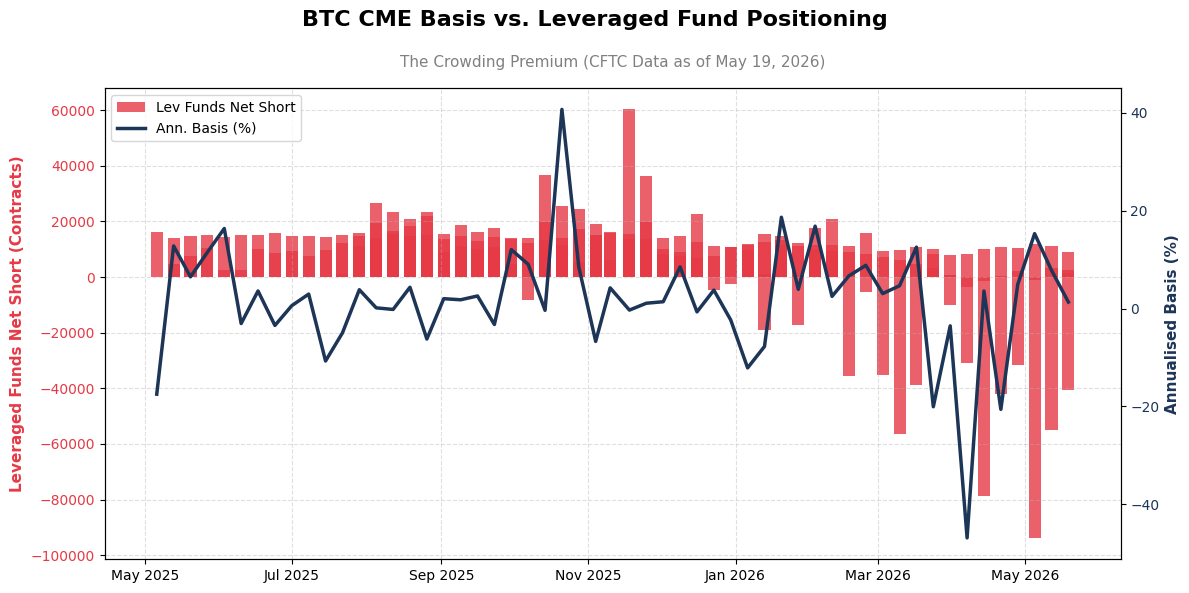

In [10]:
import requests
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def build_cot_chart_colab():
    # 1. Fetch CFTC Data (WITH THE BITCOIN FILTER FIX)
  # 1. Fetch CFTC Data (WITH FUZZY SODA API FILTER)
    url = "https://publicreporting.cftc.gov/resource/gpe5-46if.json"
    params = {
        "$where": "contract_market_name LIKE '%BITCOIN%'", # Fuzzy search ignores trailing spaces
        "$order": "report_date_as_yyyy_mm_dd DESC",
        "$limit": 156
    }

    print("Fetching 3-year CFTC CoT Data...")
    response = requests.get(url, params=params)
    response.raise_for_status()
    cot_df = pd.DataFrame(response.json())

    if cot_df.empty:
        print("Error: No data returned from CFTC API.")
        return

    # Process Leveraged Funds Net Short
    # Ensure CFTC date is explicitly timezone-naive
    cot_df['Date'] = pd.to_datetime(cot_df['report_date_as_yyyy_mm_dd']).dt.tz_localize(None)
    cot_df['Lev_Short'] = pd.to_numeric(cot_df['lev_money_positions_short'])
    cot_df['Lev_Long'] = pd.to_numeric(cot_df['lev_money_positions_long'])
    cot_df['Net_Short'] = cot_df['Lev_Short'] - cot_df['Lev_Long']
    cot_df = cot_df[['Date', 'Net_Short']].sort_values('Date').set_index('Date')

    # 2. Fetch Pricing Data for Basis
    print("Fetching pricing data for basis overlay...")
    start_date = cot_df.index.min().strftime('%Y-%m-%d')

    # Use yf.download to prevent bot-blocking
    price_data = yf.download(["BTC-USD", "BTC=F"], start=start_date, progress=False)

    # Safety Check for Yahoo Finance Rate Limits
    if price_data.empty or 'Close' not in price_data:
        print("Error: Yahoo Finance returned no data (rate-limited).")
        return

    spot = price_data['Close']['BTC-USD'].dropna()
    fut = price_data['Close']['BTC=F'].dropna()

    # Strip timezones so Pandas can merge the datasets perfectly
    spot.index = pd.to_datetime(spot.index).tz_localize(None)
    fut.index = pd.to_datetime(fut.index).tz_localize(None)

    # Calculate basis
    ann_basis = ((fut / spot) - 1) * (365 / 30) * 100
    ann_basis.name = 'Ann_Basis_Pct'

    # 3. Merge Datasets
    merged = cot_df.join(ann_basis, how='left')
    merged['Ann_Basis_Pct'] = merged['Ann_Basis_Pct'].ffill().bfill()

    # 4. Generate the Chart
    print("Generating chart...")
    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#ffffff')

    # Net Short Bar Chart (Risk)
    color1 = '#E63946'
    ax1.bar(merged.index, merged['Net_Short'], width=5, color=color1, alpha=0.8, label='Lev Funds Net Short')
    ax1.set_ylabel('Leveraged Funds Net Short (Contracts)', color=color1, fontweight='bold', fontsize=11)
    ax1.tick_params(axis='y', labelcolor=color1)

    # Title & Subtitle with proper spacing
    latest_date = merged.index.max().strftime('%b %d, %Y')
    fig.suptitle('BTC CME Basis vs. Leveraged Fund Positioning', fontsize=16, fontweight='bold', y=0.98)
    ax1.set_title(f"The Crowding Premium (CFTC Data as of {latest_date})", fontsize=11, color='gray', pad=15)

    # Ann Basis Line Chart (Reward)
    ax2 = ax1.twinx()
    color2 = '#1D3557'
    ax2.plot(merged.index, merged['Ann_Basis_Pct'], color=color2, linewidth=2.5, label='Ann. Basis (%)')
    ax2.set_ylabel('Annualised Basis (%)', color=color2, fontweight='bold', fontsize=11)
    ax2.tick_params(axis='y', labelcolor=color2)

    # Clean up X-Axis formatting
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    ax1.grid(True, linestyle='--', alpha=0.4)

    # Merge Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', frameon=True)

    # Apply layout constraints
    fig.tight_layout()
    fig.subplots_adjust(top=0.85)

    # Render inline in Colab
    plt.show()

# Execute the function
build_cot_chart_colab()

In [8]:
!pip install yfinance -q